In [23]:
%pip install langchain_groq  langchain_core --q

Note: you may need to restart the kernel to use updated packages.


In [24]:
import os
from dotenv import load_dotenv
load_dotenv()

from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from typing_extensions import Literal, TypedDict
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

from typing import Annotated, List
import operator


In [25]:
llm = ChatGroq(model = 'llama-3.3-70b-versatile')


In [26]:
def extract_text(content):
    if isinstance(content, str):
        return content

    if isinstance(content, list):
        return "\n".join(
            item["text"]
            for item in content
            if item.get("type") == "text"
        )

    return str(content)

In [27]:
class Section(BaseModel):
    name: str = Field(description = 'Name for this section of the report')
    description : str = Field(description  = 'Brief overview of main topics and concepts of the section')

class Sections(BaseModel):
    sections : List[Section] = Field(description = 'List of sections in the report')

planner = llm.with_structured_output(Sections)


In [28]:
from langgraph.constants import Send

class State(TypedDict):
    topic: str
    sections : List[Section]
    completed_sections : Annotated[list, operator.add]
    final_report : str


class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]

C:\Users\Sanskriti Jain\AppData\Local\Temp\ipykernel_32832\1833752792.py:1: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [29]:
def orchestrator(state: State):
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report"),
            HumanMessage(
                content=f"Here is the report topic: {state['topic']}"
            )
        ]
    )

    print("Report sections:", report_sections)

    return {"sections": report_sections.sections}


def llm_call(state: WorkerState):
    section = llm.invoke(
        [
            SystemMessage(
                content=(
                    "Write a report section following the provided name and "
                    "description. Include no preamble for each section. "
                    "Use markdown formatting."
                )
            ),
            HumanMessage(
                content=(
                    f"Section name: {state['section'].name}\n"
                    f"Section description: {state['section'].description}"
                )
            )
        ]
    )

    return {"completed_sections": [section.content]}


def assign_workers(state: State):
    return [
        Send("llm_call", {"section": s})
        for s in state["sections"]
    ]

In [30]:
def synthesizer(state: State):
    completed_sections = state['completed_sections']
    completed_report_sections = "\n\n-------\n\n".join(completed_sections)
    return {"final_report": completed_report_sections}

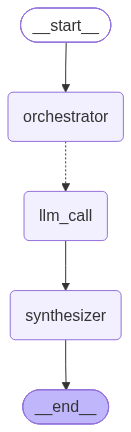

In [31]:
orchestor_worker_builder = StateGraph(State)

orchestor_worker_builder.add_node("orchestrator", orchestrator)
orchestor_worker_builder.add_node("llm_call", llm_call)
orchestor_worker_builder.add_node("synthesizer", synthesizer)

orchestor_worker_builder.add_edge(START, "orchestrator")

orchestor_worker_builder.add_conditional_edges(
    "orchestrator",
    assign_workers,
    ["llm_call"]
)

orchestor_worker_builder.add_edge("llm_call", "synthesizer")
orchestor_worker_builder.add_edge("synthesizer", END)

orchestrator_workflow = orchestor_worker_builder.compile()

graph_image = orchestrator_workflow.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [34]:
state = orchestrator_workflow.invoke({"topic": "create a report on Political instability in Myanmaar"})

Report sections: sections=[Section(name='Introduction', description='Overview of Myanmar and its history of political instability'), Section(name='Causes of Instability', description='Analysis of the factors contributing to political instability in Myanmar, including ethnic conflicts and military rule'), Section(name='Effects of Instability', description="Examination of the impact of political instability on Myanmar's economy, human rights, and international relations"), Section(name='International Response', description="Discussion of the international community's response to the crisis in Myanmar, including sanctions and diplomatic efforts"), Section(name='Conclusion', description="Summary of the report's findings and recommendations for addressing political instability in Myanmar")]


In [35]:
from IPython.display import Markdown
Markdown(state['final_report'])

### Introduction
Myanmar, formerly known as Burma, is a country located in Southeast Asia with a complex and tumultuous history. The country has experienced repeated periods of political instability, with numerous military coups and uprisings throughout its history. Since gaining independence from British colonial rule in 1948, Myanmar has struggled to establish a stable and democratic government. The country's early years were marked by parliamentary democracy, but this was short-lived, as the military seized power in 1962 and established a socialist government. The subsequent decades were characterized by authoritarian rule, human rights abuses, and economic stagnation. In 2011, the military junta introduced a new constitution and held elections, which led to a transitional government and a gradual opening up of the economy. However, the country's democratic transition was cut short in 2021, when the military staged another coup, plunging Myanmar back into political turmoil. This legacy of political instability has had a profound impact on the country's development, economy, and people, and continues to shape its future.

-------

### Causes of Instability
#### Ethnic Conflicts
Myanmar's diverse ethnic landscape has been a significant contributor to the country's political instability. The nation is home to over 130 ethnic groups, each with their own distinct language, culture, and history. For decades, various ethnic armed groups have been fighting for greater autonomy, self-governance, and recognition of their rights. The most prominent of these conflicts involve the Rohingya Muslim minority in Rakhine State, the Kachin Independence Army in Kachin State, and the Karen National Union in Karen State. These conflicts have resulted in widespread human suffering, displacement, and loss of life, further exacerbating the country's instability.

#### Military Rule
The military, known as the Tatmadaw, has been the dominant force in Myanmar's politics since the country gained independence in 1948. The military has ruled the country directly for nearly five decades, and even after transitioning to a quasi-civilian government in 2011, it continues to wield significant influence over the political process. The military's grip on power has been a major obstacle to democratization and has contributed to the country's instability. The military's actions, including the suppression of dissent and the persecution of minority groups, have created an environment of fear and mistrust, undermining the legitimacy of the government and fueling further instability.

#### Economic Factors
Economic inequality and poverty have also played a significant role in Myanmar's instability. The country's economy has been plagued by corruption, cronyism, and mismanagement, leading to widespread poverty and discontent. The lack of economic opportunities and basic services, such as healthcare and education, has created a sense of desperation and frustration among the population, which has contributed to the country's instability. The military's control over key sectors of the economy, including natural resources and state-owned enterprises, has further exacerbated the problem, as it has limited opportunities for economic growth and development.

#### International Factors
International factors, including the influence of neighboring countries and global powers, have also contributed to Myanmar's instability. The country's strategic location has made it a focal point for regional competition, with China, India, and other countries vying for influence and access to its natural resources. This has created an environment of geopolitical tension, which has further destabilized the country. Additionally, the international community's response to Myanmar's human rights abuses and political repression has been inconsistent and often ineffective, allowing the military to continue its repressive policies with relative impunity.

-------

### Effects of Instability
#### Economic Impact
Political instability has severely affected Myanmar's economy, leading to a significant decline in foreign investment, trade, and tourism. The ongoing violence and unrest have disrupted supply chains, causing shortages of essential goods and driving up prices. The country's GDP growth rate has slowed down, and the poverty rate has increased, exacerbating the already dire economic conditions.

#### Human Rights Consequences
The political instability in Myanmar has resulted in a significant deterioration of human rights, particularly for minority groups. The military crackdown on protesters and civilians has led to numerous reports of arbitrary arrests, torture, and extrajudicial killings. The Rohingya Muslim minority has been disproportionately affected, with many forced to flee their homes and seek refuge in neighboring countries. The international community has condemned the human rights abuses, imposing sanctions on the military regime.

#### International Relations
Myanmar's political instability has strained its relationships with other countries, particularly in the West. The international community has imposed economic sanctions, suspended diplomatic ties, and criticized the military regime's human rights record. The country's relations with neighboring countries, such as China and India, have also been affected, as they have been forced to navigate the complex geopolitical landscape. The ASEAN regional bloc has attempted to facilitate dialogue and mediation, but progress has been slow, and the situation remains volatile.

-------

### International Response
The international community has responded to the crisis in Myanmar with a mix of sanctions and diplomatic efforts. 
* The United States, European Union, and United Kingdom have imposed sanctions on Myanmar's military leaders and entities, targeting their economic interests and limiting their access to international finance.
* The United Nations has played a key role in condemning the violence and human rights abuses, with the Security Council passing several resolutions calling for an end to the violence and the restoration of democracy.
* The Association of Southeast Asian Nations (ASEAN) has also been involved in diplomatic efforts, with some member states calling for the release of detained leaders and an end to the violence.
* China and Russia have been criticized for their lack of action, with both countries vetoing UN Security Council resolutions on Myanmar and continuing to provide diplomatic and economic support to the military regime.
* The international community has also provided significant humanitarian aid to those affected by the crisis, with the UN and other organizations providing food, shelter, and medical care to displaced persons and refugees.
* Despite these efforts, the international response has been criticized for being inadequate and ineffective, with many arguing that more needs to be done to pressure the military regime to restore democracy and respect human rights.

-------

### Conclusion
In summary, the report's findings highlight the complex and deeply ingrained nature of political instability in Myanmar. The country's history of military rule, ethnic conflicts, and economic struggles have all contributed to the current state of instability. Key findings include:
* The need for genuine political reform and democratization to address the root causes of instability
* The importance of inclusive economic development to reduce poverty and inequality
* The requirement for a comprehensive approach to resolving ethnic conflicts and promoting national reconciliation
Based on these findings, the report recommends:
* The international community to support Myanmar's transition to democracy through targeted assistance and diplomatic engagement
* The government of Myanmar to prioritize inclusive economic development and implement policies to reduce poverty and inequality
* The establishment of a national dialogue process to address ethnic conflicts and promote national reconciliation
Ultimately, addressing political instability in Myanmar will require a sustained and collective effort from all stakeholders, including the government, civil society, and the international community. By working together and prioritizing inclusive development, democratization, and national reconciliation, it is possible to build a more stable and prosperous future for the people of Myanmar.